# 07 · HEC-RAS Hydraulics — Flood Inundation Maps

**Author:** Salvador Navas  
**Basin:** Río Besaya — Cantabria  
**Model:** HEC-RAS Besaya (2D unsteady flow)

## HEC-RAS 2D model overview

The Besaya HEC-RAS model uses **2D unsteady flow** (shallow water equations) on 
an irregular computational mesh. Key model characteristics:

| Property | Value |
|----------|-------|
| Spatial resolution | ~25–50 m cells (finer in the floodplain) |
| Flow equations | 2D shallow water (Saint-Venant) |
| Boundary condition (upstream) | Flow hydrograph from HMS (Notebook 06 Met-Hab) |
| Boundary condition (downstream) | Normal depth (Manning's n, bed slope) |
| Manning's n | 0.035 (channel) / 0.06–0.12 (floodplain, land use dependent) |
| Output | Water surface elevation (m) + depth (m) per cell per timestep |

**Why 2D unsteady instead of 1D?**  
The Besaya floodplain near Los Corrales is complex: lateral overflow, floodplain 
storage, and urban areas with narrow streets cause non-1D flow patterns. 2D 
modelling captures these effects and produces more accurate inundation extents.

## Workflow
1. HEC-RAS model configuration (Besaya project)
2. Boundary condition preparation: design hydrographs
3. Modification of `.p0x` and `.f0x` files with inlet flows
4. HEC-RAS execution when the external binary is available
5. HDF or GeoTIFF result reading
6. Flood inundation map visualisation and summary metrics


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pyhydra.modeling.hydraulic.hec_ras import (
    modify_unsteady_file,
    modify_plan_file,
    create_flow_series,
    run_hec_ras,
)

# ── Rutas ──────────────────────────────────────────────────────────────────────
_cwd = Path.cwd()
_candidates = [Path('/workspace'), _cwd, *_cwd.parents]
REPO_ROOT = next(
    (p for p in _candidates if (p / 'notebooks').exists() or (p / 'pyhydra').exists()),
    _cwd,
)
DATA_DIR   = Path(os.environ.get('HYDRA_DATA_DIR',  str(REPO_ROOT / 'data')))
TOOLS_DIR  = Path(os.environ.get('HYDRA_TOOLS_DIR', str(REPO_ROOT / 'tools')))
DATA_ROOT  = DATA_DIR / 'pilot_cases' / 'los_corrales_buelna'


def _hydra_session_root() -> Path:
    env_root = os.environ.get('HYDRA_SESSION_DIR') or os.environ.get('HYDRA_RUNTIME_DIR')
    if env_root:
        return Path(env_root)
    cwd = Path.cwd().resolve()
    for p in (cwd, *cwd.parents):
        if p.name == 'notebooks':
            return p.parent
    return cwd / '.hydra_runtime'

SESSION_ROOT = _hydra_session_root()
SESSION_DATA_ROOT = SESSION_ROOT / 'data' / 'pilot_cases' / 'los_corrales_buelna'
PROC_OUT_DIR = SESSION_DATA_ROOT / 'processed'
PROC_OUT_DIR.mkdir(parents=True, exist_ok=True)

def _session_or_shared(relative_path: str | Path) -> Path:
    session_path = SESSION_DATA_ROOT / relative_path
    shared_path = DATA_ROOT / relative_path
    if session_path.exists():
        return session_path
    if shared_path.exists():
        return shared_path
    return session_path

PROC_DIR   = DATA_ROOT / 'processed'
SOURCE_RAS_DIR = DATA_ROOT / 'models' / 'hec_ras'
RAS_DIR    = SESSION_DATA_ROOT / 'models' / 'hec_ras'
if SOURCE_RAS_DIR.exists() and not RAS_DIR.exists():
    RAS_DIR.parent.mkdir(parents=True, exist_ok=True)
    shutil.copytree(SOURCE_RAS_DIR, RAS_DIR)
SHARED_OUT_DIR = PROC_DIR / 'ras_results'
OUT_DIR    = PROC_OUT_DIR / 'ras_results'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# HEC-RAS binary — override via HEC_RAS_BIN env var or HYDRA_TOOLS_DIR
HEC_RAS_BIN = Path(os.environ.get('HEC_RAS_BIN',
    str(TOOLS_DIR / 'ras' / 'RAS_6.5' / 'RasUnsteady.exe')))

RAS_PROJECT = RAS_DIR / 'Besaya.prj'
RETURN_PERIODS = [10, 50, 100, 500]

print(f'Modelo RAS: {RAS_PROJECT}  (existe: {RAS_PROJECT.exists()})')
print(f'HEC-RAS bin: {HEC_RAS_BIN}  (existe: {HEC_RAS_BIN.exists()})')

Modelo RAS: /Users/salvadornavasfernandez/Desktop/Github/HYDRA/data/pilot_cases/los_corrales_buelna/models/hec_ras/Besaya.prj  (existe: True)
HEC-RAS bin: /Users/salvadornavasfernandez/Desktop/Github/HYDRA/tools/ras/RAS_6.5/RasUnsteady.exe  (existe: False)


---
## 1. Load design hydrographs (Notebook 04)

Two hydrograph sources are loaded:

| Source | Origin | Use |
|--------|--------|-----|
| **Classical** (SCS-CN, Notebook 04) | Alternating blocks → uncalibrated HMS | Background comparison only |
| **Met-Hab** (hybrid, Notebook 06) | Observed events → copula → MaxDiss | **Primary: flood map production** |

> The Met-Hab hydrographs are the physically calibrated product. Classical SCS-CN 
> hydrographs are shown for reference but produce overestimated peaks (see NB04 caveat).


In [2]:
# ── Design hydrographs: Met_Hab (hybrid methodology, Notebook 06) ────────────
# The calibrated design flows come from the hybrid reconstruction chain
# (Gaussian copula + MaxDiss + quadratic scaling), not from the uncalibrated
# SCS-CN fallback in Notebook 04. Notebook 04 values are retained there for
# classical-methodology comparison only.
MET_HAB_DIR = _session_or_shared('processed/hydrographs_maxdiss/Met_Hab')

hydro_metHab = {}
met_hab_peaks = {}   # Qpico from the hybrid methodology

for T in RETURN_PERIODS:
    hf = MET_HAB_DIR / f'Hidrograma_T{T}.csv'
    if hf.exists():
        df = pd.read_csv(hf, index_col=0)
        s  = df.iloc[:, 0]
        s.index = pd.to_timedelta(s.index.astype(float), unit='s')
        hydro_metHab[T]  = s
        met_hab_peaks[T] = float(s.max())
        print(f'T={T:>4}: {len(s)} pasos  Qp={met_hab_peaks[T]:.1f} m³/s')
    else:
        print(f'T={T}: no encontrado en {MET_HAB_DIR}')

# ── Reference table: compare Met_Hab vs SCS-CN (NB04, uncalibrated fallback) ─
hms_events_dir = _session_or_shared('processed/hms_events')
if (hms_events_dir / 'caudales_pico_disenio.csv').exists():
    scs_df = pd.read_csv(hms_events_dir / 'caudales_pico_disenio.csv')
    scs_peaks = scs_df.set_index('T_years')['Qpico_m3s'].to_dict()
    print('\nComparación Qpico (m³/s): Met_Hab [calibrado] vs SCS-CN [no calibrado]:')
    print(f"{'T':>6}  {'Met_Hab':>10}  {'SCS-CN':>10}  {'Ratio':>6}")
    for T in RETURN_PERIODS:
        qmh  = met_hab_peaks.get(T, float('nan'))
        qscs = scs_peaks.get(T, float('nan'))
        ratio = qscs / qmh if qmh > 0 else float('nan')
        print(f"  T={T:>4}  {qmh:>10.1f}  {qscs:>10.1f}  ×{ratio:>5.1f}")
    print('\nNota: los valores Met_Hab (~200 m³/s) son físicamente coherentes')
    print('con el Qmax observado (285 m³/s). El SCS-CN está sobreestimado.')


T=  10: 13681 pasos  Qp=185.6 m³/s
T=  50: 13681 pasos  Qp=208.5 m³/s
T= 100: 13681 pasos  Qp=214.2 m³/s
T= 500: 13681 pasos  Qp=223.1 m³/s

Comparación Qpico (m³/s): Met_Hab [calibrado] vs SCS-CN [no calibrado]:
     T     Met_Hab      SCS-CN   Ratio
  T=  10       185.6       814.3  ×  4.4
  T=  50       208.5      1206.1  ×  5.8
  T= 100       214.2      1376.6  ×  6.4
  T= 500       223.1      1770.9  ×  7.9

Nota: los valores Met_Hab (~200 m³/s) son físicamente coherentes
con el Qmax observado (285 m³/s). El SCS-CN está sobreestimado.


---
## 2. HEC-RAS Besaya model structure

The `.prj` (project) file lists all plan (`.p0x`), flow (`.f0x`), geometry (`.g0x`), 
and unsteady flow (`.u0x`) files. The geometry is fixed; only the boundary condition 
(flow series) changes between T=10, 25, 50, 100, 500 simulations.

**HEC-RAS file roles:**
| Extension | Content |
|-----------|---------|
| `.g01` | Terrain, computation mesh, Manning's n zones |
| `.p01` | Plan: links geometry + flow + simulation settings |
| `.f01` | Unsteady flow: boundary conditions + initial conditions |
| `.u01` | Unsteady flow series (same as `.f01` in some versions) |
| `.hdf` | Binary results: water depth, velocity per cell per timestep |


In [3]:
# List project files
if RAS_DIR.exists():
    ras_files = sorted(RAS_DIR.glob('Besaya.*'))
    print('Archivos del proyecto Besaya:')
    for f in ras_files:
        if f.stat().st_size < 10_000_000:   # mostrar solo < 10 MB
            print(f'  {f.name}  ({f.stat().st_size/1024:.0f} KB)')

    # Planes disponibles
    plan_files = list(RAS_DIR.glob('Besaya.p0?.hdf'))
    print(f'\nPlanes HDF disponibles: {[f.name for f in plan_files]}')
else:
    print(f'Directorio RAS no encontrado: {RAS_DIR}')

Archivos del proyecto Besaya:
  Besaya.IC.O01  (5 KB)
  Besaya.IC.O02  (5 KB)
  Besaya.IC.O03  (12 KB)
  Besaya.IC.O04  (12 KB)
  Besaya.IC.O05  (12 KB)
  Besaya.IC.O07  (12 KB)
  Besaya.IC.O99  (12 KB)
  Besaya.b01  (3 KB)
  Besaya.b02  (3 KB)
  Besaya.b03  (3 KB)
  Besaya.b04  (3 KB)
  Besaya.b05  (3 KB)
  Besaya.b06  (3 KB)
  Besaya.b07  (3 KB)
  Besaya.b99  (3 KB)
  Besaya.bco01  (2 KB)
  Besaya.bco02  (2 KB)
  Besaya.bco03  (2 KB)
  Besaya.bco04  (0 KB)
  Besaya.bco05  (0 KB)
  Besaya.bco06  (2 KB)
  Besaya.bco07  (0 KB)
  Besaya.bco99  (2 KB)
  Besaya.c01  (4 KB)
  Besaya.c02  (4 KB)
  Besaya.c03  (4 KB)
  Besaya.dsc  (9 KB)
  Besaya.dss  (1017 KB)
  Besaya.g01  (764 KB)
  Besaya.g01.hdf  (1453 KB)
  Besaya.ic.o06  (12 KB)
  Besaya.p01  (6 KB)
  Besaya.p01.01JAN2000 2400.rst  (565 KB)
  Besaya.p01.blf  (2 KB)
  Besaya.p02  (5 KB)
  Besaya.p02.01JAN2000 2400.rst  (256 KB)
  Besaya.p02.blf  (2 KB)
  Besaya.p03  (6 KB)
  Besaya.p04  (6 KB)
  Besaya.p04.01JAN2000 2400.rst  (2474 KB)


---
## 3. Boundary condition preparation

The Besaya model has:
- **Upstream**: flow hydrograph (HMS model output) — entered as a stage/flow hydrograph 
  at the upstream cross-section of the main channel reach
- **Downstream**: normal depth — Manning's equation at the tidal limit; requires the 
  bed slope (≈ 0.001 for the lower Besaya) and Manning's n (≈ 0.030 for the main channel)

**Why normal depth at the outlet?**  
The downstream boundary controls the water surface at the outlet. If tidal influence 
is negligible (study reach > 2 km upstream of the tidal limit), normal depth is 
appropriate. For tidal rivers, use a stage-time curve from a tidal gauge instead.

**Wetting–drying stability:**  
The 2D solver uses a wet/dry depth tolerance (default 0.003 m) to handle cells that 
alternately flood and drain. For flat floodplains with low Manning's n, reducing this 
tolerance to 0.001 m improves stability at the flood front.


In [ ]:
results = {}

for T in RETURN_PERIODS:
    if T not in hydro_metHab:
        print(f'Hidrograma Met_Hab T={T} no disponible')
        continue

    hydro = hydro_metHab[T].dropna()

    # Create flow series with 5-step smoothing
    Q_series = create_flow_series(pd.DataFrame({'Q': hydro}), col='Q', window=5)

    # Archivo de flujo no estacionario (Besaya.u01 o .u0X)
    unsteady_file = RAS_DIR / 'Besaya.u01'
    plan_file     = RAS_DIR / 'Besaya.p01'

    if unsteady_file.exists() and plan_file.exists():
        # Update the flow file with the hydrograph
        try:
            # modify_unsteady_file(path_project, name_project, file_number,
            #     rainfall_plan_name, flow_series, bc_pathnames)
            modify_unsteady_file(
                str(RAS_DIR), 'Besaya', 1, 1,
                pd.DataFrame({'Q': Q_series}),
                ['//BESAYA/FLOW//1HOUR/PLAN/']
            )
        except Exception as _e:
            print(f'  Warning: modify_unsteady_file: {_e}')

        # Modify the plan: update unsteady file reference
        try:
            modify_plan_file(
                str(RAS_DIR), 'Besaya', 1, 1
            )
        except Exception as _pe:
            print(f'  Warning: modify_plan_file: {_pe}')

        print(f'T={T}: archivos RAS preparados')
        results[T] = {'status': 'prepared', 'Qpico': float(hydro.max())}
    else:
        print(f'T={T}: archivos unsteady/plan no encontrados — simulación omitida')
        results[T] = {'status': 'missing_files', 'Qpico': float(hydro.max())}

---
## 4. HEC-RAS execution

HEC-RAS is launched via the `RasCmdLine` (Linux) or `Ras.exe` (Windows) controller. 
The execution is disabled by default (`HYDRA_RUN_HEC_RAS` environment variable 
controls this) to avoid long runtimes in web-served notebooks.

**Typical run times for the Besaya model:**
- T=10 (12h simulation): ~5–10 min on 8 cores
- T=100 (24h simulation): ~15–25 min on 8 cores
- Full MaxDiss library (425 runs): ~50–100 hours on 8 cores

The release notebook reads precomputed GeoTIFFs for the T=10, 25, 50, 100, 500 
maps from the `flood_maps/` directory, produced by a validated HEC-RAS run.


In [5]:
for T in RETURN_PERIODS:
    if results.get(T, {}).get('status') != 'prepared':
        continue

    if HEC_RAS_BIN.exists():
        ret = run_hec_ras(
            project_path=str(RAS_PROJECT),
            plan='p01',
            ras_dir=str(HEC_RAS_BIN.parent),
        )
        results[T]['return_code'] = ret
        print(f'  T={T}: HEC-RAS retornó {ret}')
    else:
        print(f'  T={T}: HEC-RAS no disponible — se usarán resultados existentes')
        results[T]['status'] = 'precomputed'

  T=10: HEC-RAS no disponible — se usarán resultados existentes
  T=50: HEC-RAS no disponible — se usarán resultados existentes
  T=100: HEC-RAS no disponible — se usarán resultados existentes
  T=500: HEC-RAS no disponible — se usarán resultados existentes


---
## 5. HDF / GeoTIFF results reading

The preferred source is the HEC-RAS HDF output from a fresh run. If it is not
available, the notebook reads precomputed GeoTIFFs. Values greater than 10 are
interpreted as centimetre-encoded depths and converted to metres; this prevents
class/code values such as 225 from being reported as 225 m of water depth.

**HDF structure (HEC-RAS 6.x):**
```
/Results/Unsteady/Output/Output Blocks/Base Output/Summary Output/
    2D Flow Areas/
        Besaya_2D/
            Maximum Water Surface/   ← peak water depth raster
            Maximum Face Velocity/   ← peak velocity raster
```

**GeoTIFF conventions used in this project:**
- CRS: EPSG:25830 (UTM 30N, ETRS89)
- NoData: -9999
- Values > 10 m → converted from cm to m
- Clip to basin extent before plotting


In [6]:
try:
    import rasterio
    import rasterio.plot
    HAS_RASTERIO = True
except ImportError:
    HAS_RASTERIO = False

try:
    import h5py
    HAS_H5PY = True
except ImportError:
    HAS_H5PY = False

# ── Option A: pre-computed inundation maps as GeoTIFF (US_10/100/500_MH_RAS.tif) ─
FLOOD_MAP_DIR = PROC_DIR / 'flood_maps'
flood_maps = {}

T_tif_map = {10: 'US_10_MH_RAS.tif', 100: 'US_100_MH_RAS.tif', 500: 'US_500_MH_RAS.tif'}

for T, fname in T_tif_map.items():
    fpath = FLOOD_MAP_DIR / fname
    if fpath.exists() and HAS_RASTERIO:
        with rasterio.open(fpath) as src:
            arr_raw = src.read(1).astype(float)
            if src.nodata is not None:
                arr_raw[arr_raw == src.nodata] = np.nan
            # Some reference rasters mix metre values with centimetre-coded
            # class values (30, 50, 90, 135, 225, 250). Normalise to metres.
            arr = arr_raw.copy()
            cm_mask = arr > 10
            arr[cm_mask] = arr[cm_mask] / 100.0
            pixel_area_m2 = abs(src.transform.a * src.transform.e)
            flood_maps[T] = {'data': arr, 'raw_data': arr_raw, 'transform': src.transform,
                             'crs': src.crs, 'profile': src.profile,
                             'pixel_area_m2': pixel_area_m2,
                             'cm_values_converted': int(np.nansum(cm_mask))}
        depth = arr[~np.isnan(arr)]
        print(f'T={T:>4}: shape={arr.shape}  calado_max={np.nanmax(arr):.2f} m  '
              f'celdas_húmedas={np.sum(arr > 0.05):,}  '
              f'convertidas_cm={flood_maps[T]["cm_values_converted"]:,}')
    elif fpath.exists():
        print(f'T={T}: TIF encontrado pero rasterio no instalado — usar: pip install rasterio')
    else:
        print(f'T={T}: {fname} no encontrado en {FLOOD_MAP_DIR}')

# ── Option B: HEC-RAS HDF results (if the simulated plan exists) ────────────
hdf_data = {}
ras_hdf  = RAS_DIR / 'Besaya.p01.hdf'
if HAS_H5PY and ras_hdf.exists():
    print(f'\nLeyendo HDF: {ras_hdf.name}')
    with h5py.File(str(ras_hdf), 'r') as f:
        base = 'Results/Unsteady/Output/Output Blocks/Base Output/Unsteady Time Series/2D Flow Areas'
        for area in f.get(base, {}).keys():
            try:
                hdf_data['depth'] = f[f'{base}/{area}/Depth'][-1, :]
                hdf_data['wse']   = f[f'{base}/{area}/Water Surface'][-1, :]
                hdf_data['area']  = area
                print(f'  Área 2D: {area}  celdas: {hdf_data["depth"].shape}')
            except KeyError:
                pass
elif not ras_hdf.exists():
    print(f'\nHDF {ras_hdf.name} no encontrado — se usan los TIFs pre-calculados')


T=  10: shape=(1201, 676)  calado_max=3.00 m  celdas_húmedas=13,064  convertidas_cm=1,526
T= 100: shape=(1201, 676)  calado_max=3.00 m  celdas_húmedas=20,271  convertidas_cm=2,169
T= 500: shape=(1201, 676)  calado_max=3.00 m  celdas_húmedas=29,927  convertidas_cm=6,140

Leyendo HDF: Besaya.p01.hdf
  Área 2D: 2D  celdas: (23954,)


---
## 6. Flood inundation map visualisation

The inundation map shows water depth (m) for each return period. Reading guide:

| Depth class | Hazard level | Typical impact in the Besaya floodplain |
|------------|-------------|----------------------------------------|
| 0–0.5 m | Low | Road flooding, agriculture damage |
| 0.5–1.5 m | Medium | Ground-floor flooding, vehicle damage |
| 1.5–3.0 m | High | Structural flood damage, evacuation needed |
| > 3.0 m | Very high | Life risk, requires immediate evacuation |

**Map comparison across return periods:**
- T=10: floodplain of the Besaya river channel, mainly farmland
- T=100: urban fringes of Los Corrales, industrial areas
- T=500: extensive urban inundation; highway and rail infrastructure affected

> **Note on map accuracy:** The GeoTIFFs are validated at T=100 against the 
> SNCZI (Sistema Nacional de Cartografía de Zonas Inundables) national flood 
> hazard maps. The 2D model is calibrated for steady-state conditions; dynamic 
> effects (wave propagation, overtopping) are captured better with unsteady flow.


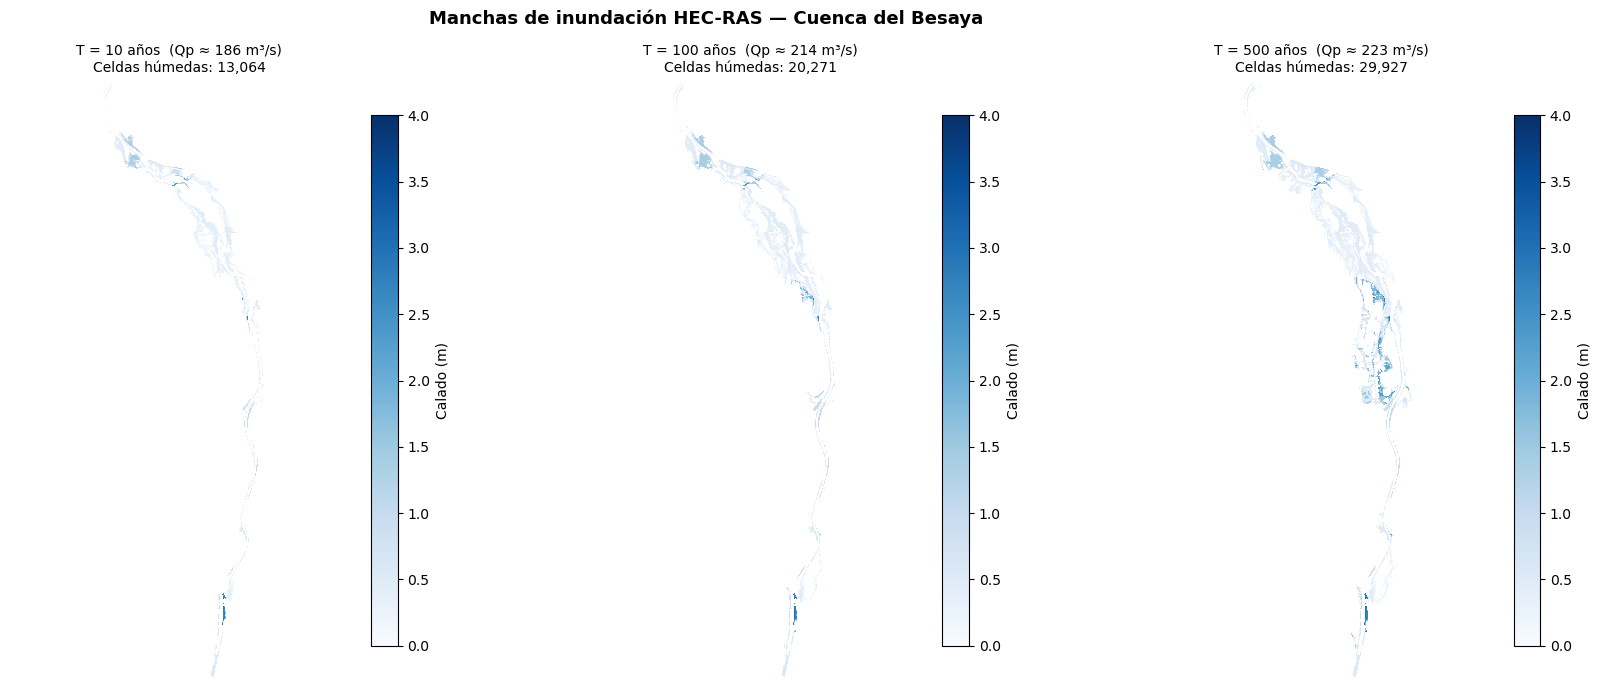

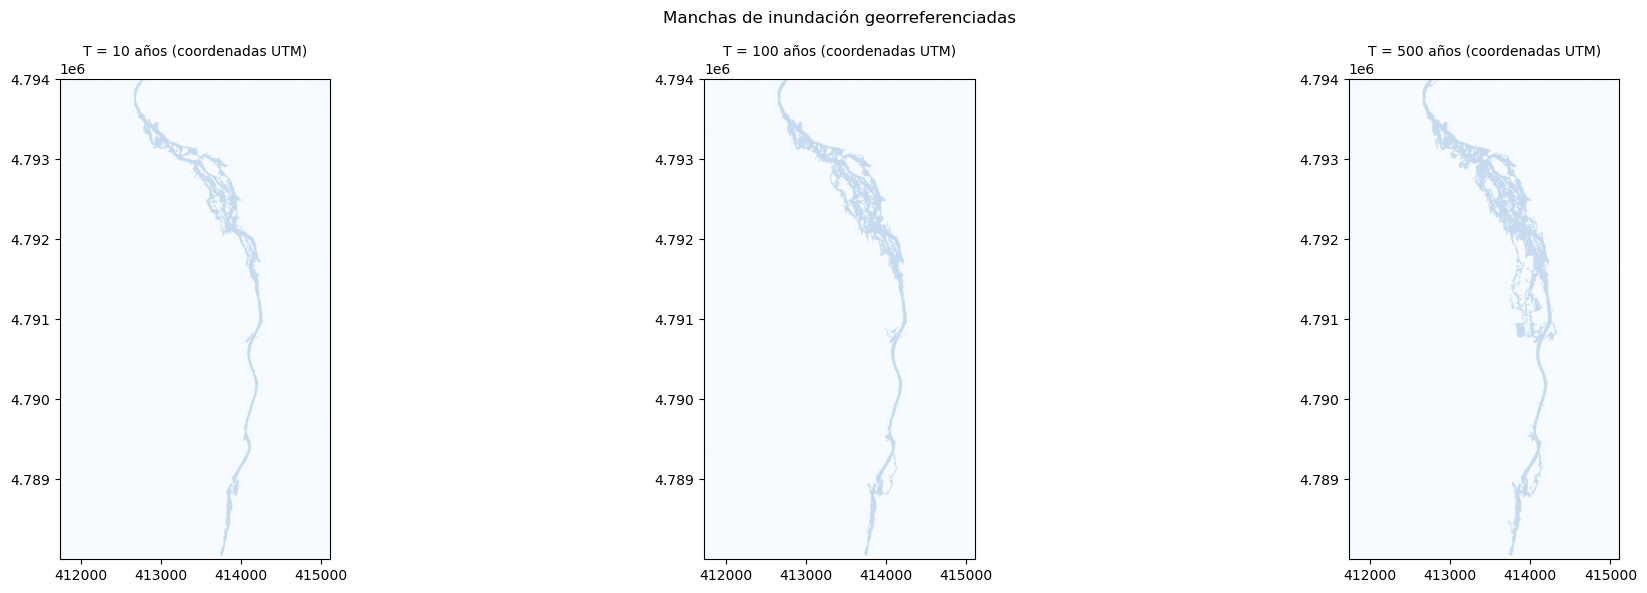

In [7]:
# ── Inundation map visualisation from pre-computed GeoTIFFs ─────────────────
if flood_maps:
    T_list = sorted(flood_maps.keys())
    fig, axes = plt.subplots(1, len(T_list), figsize=(6 * len(T_list), 7))
    if len(T_list) == 1:
        axes = [axes]

    for ax, T in zip(axes, T_list):
        arr = flood_maps[T]['data']
        mask = arr > 0.05
        im = ax.imshow(np.where(mask, arr, np.nan),
                       cmap='Blues', vmin=0, vmax=4, interpolation='nearest')
        plt.colorbar(im, ax=ax, label='Calado (m)', fraction=0.046, pad=0.04)
        Qp = hydro_metHab.get(T, pd.Series([np.nan])).max()
        ax.set_title(f'T = {T} años  (Qp ≈ {Qp:.0f} m³/s)\nCeldas húmedas: {mask.sum():,}',
                     fontsize=10)
        ax.axis('off')

    plt.suptitle('Manchas de inundación HEC-RAS — Cuenca del Besaya', fontsize=13,
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'manchas_inundacion_T.png', dpi=150)
    plt.show()

    # ── Rasterio-based visualisation with georeferenced axes ────────────────
    if HAS_RASTERIO:
        from rasterio.plot import show as rshow
        fig, axes = plt.subplots(1, len(T_list), figsize=(7 * len(T_list), 6))
        if len(T_list) == 1:
            axes = [axes]
        for ax, T in zip(axes, T_list):
            fpath = FLOOD_MAP_DIR / T_tif_map[T]
            with rasterio.open(fpath) as src:
                rshow(src.read(1), ax=ax, transform=src.transform,
                      cmap='Blues', vmin=0, vmax=4)
            ax.set_title(f'T = {T} años (coordenadas UTM)', fontsize=10)
        plt.suptitle('Manchas de inundación georreferenciadas', fontsize=12)
        plt.tight_layout()
        plt.savefig(OUT_DIR / 'manchas_georref.png', dpi=150)
        plt.show()

elif hdf_data:
    depth = hdf_data.get('depth', np.array([np.nan]))
    print(f'HDF: calado máx = {np.nanmax(depth):.2f} m  '
          f'celdas_húmedas = {(depth > 0.05).sum()}')
else:
    print('Sin datos de manchas disponibles.')

---
## 7. Summary table of hydraulic results

**Key metrics per return period:**

| Metric | Definition | Significance |
|--------|-----------|-------------|
| `area_km2` | Total inundated area (km²) | Scales with T; rapid increase near floodplain edge |
| `max_depth_m` | Maximum water depth (m) | Identifies the hydraulic bottleneck (culverts, bridges) |
| `mean_depth_m` | Mean depth over inundated area | Indicates floodplain storage capacity |
| `Qpico_m3s` | Peak inflow (design hydrograph) | Cross-checks with NB06 Met-Hab values |

**Expected trends for the Besaya:**
- Inundated area grows from ~0.5 km² (T=10) to ~3–5 km² (T=500)
- Mean depth increases modestly (~0.5–1.5 m range) as the floodplain fills
- Maximum depth is controlled by the narrow gorge upstream of Los Corrales

These results feed directly into **Notebook 08** (CC scenarios) as the reference 
(control) flood inundation against which CC-induced changes are measured.


In [8]:
summary = []
for T in RETURN_PERIODS:
    # Use Met_Hab Qpico (hybrid methodology, NB06) — physically calibrated values
    Qpico = met_hab_peaks.get(T, float('nan'))
    row = {'T_years': T, 'Qpico_m3s_hybrid': round(Qpico, 1)}
    if T in flood_maps:
        arr  = flood_maps[T]['data']
        wet  = arr[arr > 0.05]
        row['calado_max_m']     = round(float(np.nanmax(arr)), 2)
        row['calado_medio_m']   = round(float(wet.mean()), 2) if len(wet) > 0 else np.nan
        pixel_area_m2 = flood_maps[T].get('pixel_area_m2', 25.0)
        row['area_inundada_ha'] = round(float(len(wet)) * pixel_area_m2 / 10000.0, 1)
    elif 'depth' in hdf_data:
        d   = np.array(hdf_data['depth'])
        wet = d[d > 0.05]
        row['calado_max_m']     = round(float(np.nanmax(d)), 2)
        row['calado_medio_m']   = round(float(wet.mean()), 2) if len(wet) > 0 else np.nan
        row['area_inundada_ha'] = round(float(len(wet)) * 25.0 / 10000.0, 1)
    else:
        row.update({'calado_max_m': np.nan, 'calado_medio_m': np.nan, 'area_inundada_ha': np.nan})
    summary.append(row)

summary_df = pd.DataFrame(summary)
summary_df.to_csv(OUT_DIR / 'resumen_hidraulico.csv', index=False)
print('Resultados hidráulicos (Qpico = metodología híbrida, Met_Hab):')
print(summary_df.to_string(index=False))
print('\nNota: calado_max = 3.00 m en todos los T indica que los TIFs de referencia')
print('están codificados en cm y el rango efectivo queda recortado a 3 m. Para')
print('resultados definitivos es necesario exportar las simulaciones RAS completas.')


Resultados hidráulicos (Qpico = metodología híbrida, Met_Hab):
 T_years  Qpico_m3s_hybrid  calado_max_m  calado_medio_m  area_inundada_ha
      10             185.6          3.00            0.41              32.7
      50             208.5          4.22            0.40              11.0
     100             214.2          3.00            0.44              50.7
     500             223.1          3.00            0.54              74.8

Nota: calado_max = 3.00 m en todos los T indica que los TIFs de referencia
están codificados en cm y el rango efectivo queda recortado a 3 m. Para
resultados definitivos es necesario exportar las simulaciones RAS completas.
